In [ ]:
!pip install efficient-apriori

In [ ]:
from efficient_apriori import apriori
import numpy as np
import pandas as pd
import graphviz

In [ ]:
df = pd.read_pickle("jogosInfo.pkl")

# Itemset mining

In [ ]:

tags = df["tags"].to_list()
tags = [tuple(listaTags) for listaTags in tags if listaTags is not None]

# tags

In [ ]:
# Aplica o algoritmo Apriori para encontrar os itemsets frequentes e regras de associação
# min_support=0.01: suporte mínimo de 1%
# min_confidence=0.90: confiança mínima de 90%

itemsets, rules = apriori(tags, min_support=0.01, min_confidence=0.90)

In [ ]:
len(rules)

28570

In [ ]:
# Inicializa uma lista vazia para armazenar as regras em formato de DataFrame
dfRules = []

# Itera sobre as regras geradas pelo algoritmo Apriori
for rule in rules:
  dfRules.append([list(rule.lhs),
                  list(rule.rhs),
                  rule.count_lhs,
                  rule.count_rhs,
                  rule.count_full,
                  rule.confidence,
                  rule.conviction,
                  rule.lift,
                  rule.support,
                  len(list(rule.lhs)),
                  len(list(rule.rhs))])
  # print(rule.lhs, rule.rhs, rule.count_lhs, rule.count_rhs, rule.confidence, rule.conviction, rule.lift, rule.support)

# Converte a lista de regras em um DataFrame com as colunas especificadas
dfRules = pd.DataFrame(dfRules, columns=["lhs", "rhs", "count lhs", "count rhs", "count full",
                                         "confidence", "conviction", "lift", "support",
                                         "size lhs", "size rhs"])

# dfRules

In [ ]:
aux = dfRules.copy()
# Filtra o DataFrame para incluir apenas regras onde o tamanho do lado esquerdo é 1
aux = aux[aux["size lhs"] == 1]

# Filtra o DataFrame para incluir apenas regras onde o tamanho do lado direito é 1
aux = aux[aux["size rhs"] == 1]

# Ordena o DataFrame pelas regras com maior lift em ordem decrescente
aux = aux.sort_values(by="lift", ascending=False)

aux.reset_index(drop=True, inplace=True)

# Exibe as colunas especificadas do DataFrame filtrado
aux[["lhs", "rhs", "lift", "count rhs", "count lhs", "count full"]]

,lhs,rhs,lift,count rhs,count lhs,count full
0,[Space Sim],[Space],17.565509,260,62,58
1,[Roguelike Deckbuilder],[Roguelike],11.207530,396,55,50
2,[NSFW],[Nudity],10.862783,409,189,172
3,[NSFW],[Sexual Content],9.672768,470,189,176
4,[Hentai],[Sexual Content],9.507891,470,189,173
5,[Open World Survival Craft],[Survival],6.813757,677,127,120
6,[Aliens],[Sci-fi],6.756268,664,111,102
7,[CRPG],[RPG],2.875367,1667,110,108
8,[Transportation],[Simulation],2.779500,1704,67,65
9,[JRPG],[RPG],2.778909,1667,313,297


In [ ]:
aux[["lhs", "rhs", "lift", "count rhs", "count lhs", "count full"]].to_csv("resultadoItemsetMining.csv")

# Classification

In [ ]:
df = pd.read_pickle("jogosInfo.pkl")
# df

In [ ]:
dictTags = dict()

# Itera sobre todas as linhas do DataFrame df
for i in range(len(df)):
  if df["tags"][i] is None:
    continue
  # Itera sobre cada tag na lista de tags da linha atual
  for tag in df["tags"][i]:
    if tag not in dictTags:
      dictTags[tag] = 0
    dictTags[tag] += 1

# Ordena o dicionário dictTags em ordem decrescente de contagem
dictTags = {k:v for k,v in sorted(dictTags.items(), key = lambda item: -item[1])}
# dictTags

In [ ]:
# Filtra as tags consideradas, excluindo aquelas que contêm "Singleplayer", "Multiplayer", ou qualquer forma de "online"
tagsConsideradas = [chave for chave, valor in dictTags.items() if
                    chave not in ["Singleplayer", "Multiplayer"] and
                    "online" not in chave.lower() and "multiplayer" not in chave.lower()]
# tagsConsideradas

In [ ]:
# Cria uma cópia do DataFrame df contendo apenas as colunas 'nome' e 'tags'
dfTags = df[["nome", "tags"]].copy()

# Define uma função que gera uma função para verificar a presença de uma tag específica
def geraFuncaoTag(tag):
  def geraColunaTag(linha):
    try:
      if tag in linha["tags"]:
        return 1
      else:
        return 0
    except:
      return 0
  return geraColunaTag

from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

# Cria uma nova coluna 'Multiplayer' no DataFrame dfTags aplicando a função geraFuncaoTag para a tag "Multiplayer"
dfTags["Multiplayer"] = dfTags.apply(geraFuncaoTag("Multiplayer"), axis=1)

# Cria novas colunas para cada tag em tagsConsideradas aplicando a função geraFuncaoTag
for tag in tagsConsideradas:
  dfTags[tag] = dfTags.apply(geraFuncaoTag(tag), axis=1)
dfTags

,nome,tags,Multiplayer,Action,Adventure,Strategy,Simulation,RPG,Indie,Atmospheric,...,Volleyball,Voice Control,Steam Machine,Hobby Sim,Bowling,Instrumental Music,Electronic Music,Tile-Matching,Rugby,Electronic
0,Counter-Strike 2,"[FPS, Shooter, Multiplayer, Competitive, Actio...",1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Dota 2,"[Free to Play, MOBA, Multiplayer, Strategy, eS...",1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,PUBG: BATTLEGROUNDS,"[Survival, Shooter, Battle Royale, Multiplayer...",1,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Apex Legends,"[Free to Play, Battle Royale, Multiplayer, FPS...",1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Source SDK Base 2007,None,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,"[Difficult, Action Roguelike, Top-Down, Action...",0,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4996,DEEEER Simulator: Your Average Everyday Deer Game,"[Exploration, Sandbox, Physics, Funny, Third P...",0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4997,Wanba Warriors,"[Fighting, Multiplayer, Funny, Parody , PvP, L...",1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4998,Coloring Game,"[Free to Play, Relaxing, Pixel Graphics, Casua...",0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Inicializa um dicionário para contar a quantidade de jogos com e sem multiplayer
aux = dict()
aux[0] = 0
aux[1] = 0

# Itera sobre a coluna 'Multiplayer' e incrementa a contagem correspondente no dicionário aux
for elemento in dfTags["Multiplayer"].to_list():
  aux[elemento] += 1
aux

{0: 2851, 1: 2149}

In [ ]:
len([elemento for elemento in dfTags["Multiplayer"].to_list() if elemento == 0])

2851

In [ ]:
# Define as tags a serem usadas na árvore de decisão
tagsTree = tagsConsideradas

# Ordena o DataFrame dfTags pela coluna 'Multiplayer' e converte as colunas de tags em um array numpy
X = dfTags.sort_values("Multiplayer")[tagsTree].to_numpy()

# Ordena o DataFrame dfTags pela coluna 'Multiplayer' e converte a coluna 'Multiplayer' em um array numpy
Y = dfTags.sort_values("Multiplayer")["Multiplayer"].to_numpy()

Y

array([0, 0, 0, ..., 1, 1, 1])

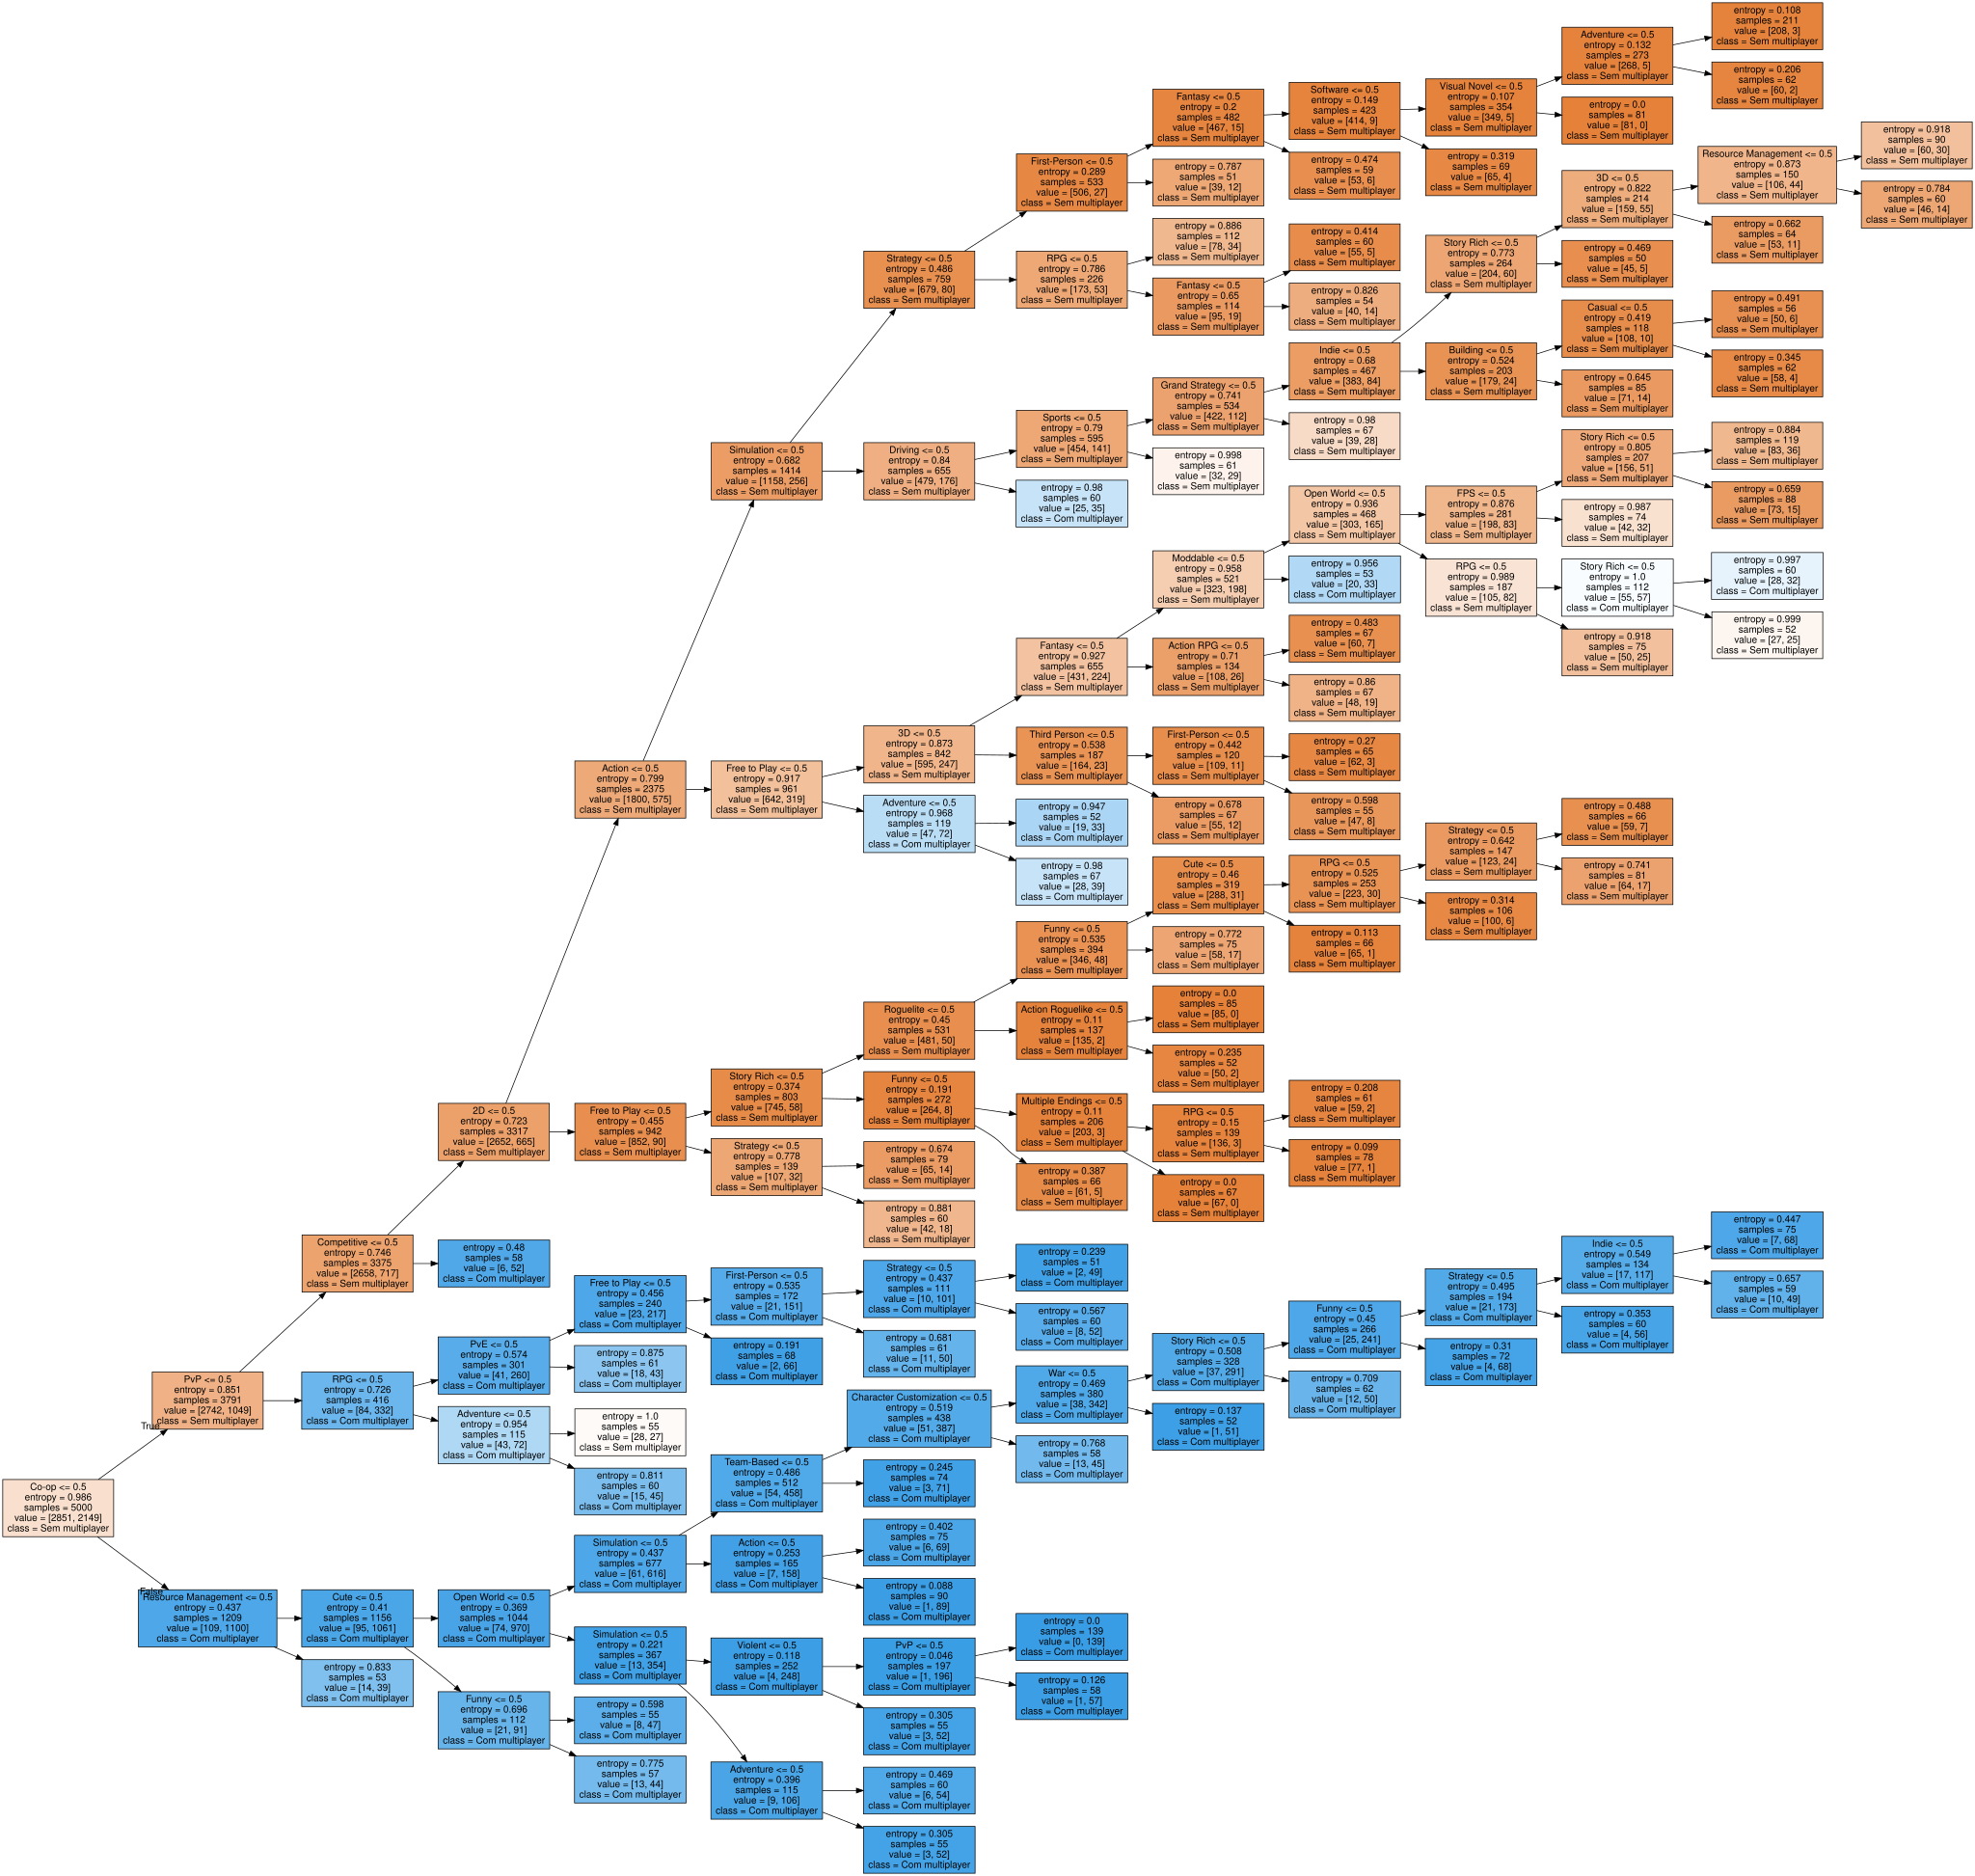

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz
import matplotlib.pyplot as plt
import graphviz

# Inicializa o classificador de árvore de decisão com os parâmetros especificados
clf = DecisionTreeClassifier(max_depth=20,
                             criterion="entropy",
                             min_samples_leaf=50)
# Treina o classificador com os dados X e Y
clf.fit(X, Y)

# plot_tree(clf, filled=True, feature_names=tagsTree, class_names=["Não", "Sim"])

# plt.figure(dpi=1)
# plt.savefig('filename.png', dpi=3000)

# print
# print(export_text(clf, feature_names=tagsTree))

# graphviz
grafo = graphviz.Source(export_graphviz(clf, feature_names=tagsTree,
                                        filled=True,
                                        # class_names=True,
                                        class_names=["Sem multiplayer", "Com multiplayer"],
                                        label="all",
                                        rotate=True))

grafo.render("filename")
grafo

In [ ]:
from google.colab import files
files.download("filename.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Limitando a 1 elementos na folha, teve f1 0.7822427499941573
Limitando a 10 elementos na folha, teve f1 0.789181038699792
Limitando a 20 elementos na folha, teve f1 0.7944910364252279
Limitando a 30 elementos na folha, teve f1 0.7943995455121349
Limitando a 40 elementos na folha, teve f1 0.7950678469292453
Limitando a 50 elementos na folha, teve f1 0.7940771058287494
Limitando a 60 elementos na folha, teve f1 0.7941538909772978
Limitando a 70 elementos na folha, teve f1 0.7929386169027868
Limitando a 80 elementos na folha, teve f1 0.7924486807818026
Limitando a 90 elementos na folha, teve f1 0.7916764816664424
Limitando a 100 elementos na folha, teve f1 0.7910612780929398
Limitando a 110 elementos na folha, teve f1 0.7900779431591025
Limitando a 120 elementos na folha, teve f1 0.7894682404080662
Limitando a 130 elementos na folha, teve f1 0.7886228365387277
Limitando a 140 elementos na folha, teve f1 0.7875451226551885
Limitando a 150 elementos na folha, teve f1 0.7862747680593941
Limi

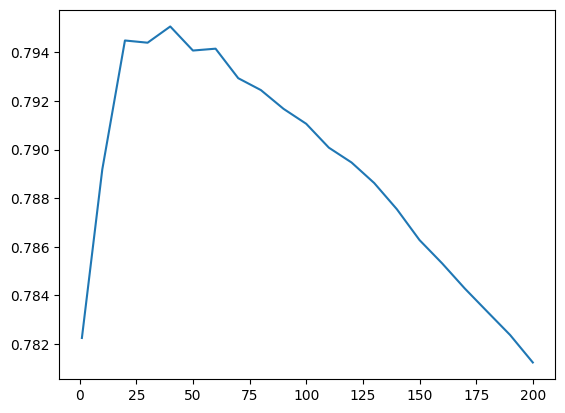

In [ ]:
# achando valor

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Inicializa uma lista para armazenar os valores de F1 score
f1List = []

# Define uma função para testar a árvore de decisão com diferentes configurações de min_samples_leaf
def funcaoTesteDecisionTree(numSplits, minLeafs):

  # Cria um objeto StratifiedKFold para realizar a validação cruzada estratificada
  skf = StratifiedKFold(n_splits=numSplits)

  # Itera sobre cada split da validação cruzada
  for i, (train_index, test_index) in enumerate(skf.split(X, Y)):
    # print(f"Fold {i}")
    # print(X[train_index].shape)
    # print(X[test_index].shape)

    # Inicializa o classificador de árvore de decisão com os parâmetros especificados
    clf = DecisionTreeClassifier(max_depth=20,
                                criterion="entropy",
                                min_samples_leaf=minLeafs)

    # Treina o classificador com os dados de treinamento do split atual
    clf.fit(X[train_index], Y[train_index])

    # Faz previsões com os dados de teste do split atual
    predict = clf.predict(X[test_index])

    # Calcula o F1 score das previsões
    f1 = f1_score(Y[test_index], predict)
    f1List.append(f1)

    # print(f"f1 = {f1}")
    # print("")


  return (sum(f1List)/len(f1List))

plotX = []
plotY = []

# Itera sobre uma lista de valores para min_samples_leaf, incluindo 1 e de 10 em 10 até 200
for numElementosFolha in [1] + list(np.arange(0, 200+1, 10))[1:]:
  f1 = funcaoTesteDecisionTree(numSplits=20, minLeafs=numElementosFolha)
  print(f"Limitando a {numElementosFolha} elementos na folha, teve f1 {f1}")

  # plt.plot(numElementosFolha, f1)
  plotX.append(numElementosFolha)
  plotY.append(f1)

# Plota os valores de min_samples_leaf (plotX) contra os F1 scores (plotY)
plt.plot(plotX, plotY)
plt.show()